<!-- config-banner -->
# DINO 1° Tapenade adjoint — 5 yr from rest, ASTE mods

**`viscGrid1p8e-2` + `adjViscBoost`** — 5 yr adjoint from rest (`nIter0=0`); `viscAhGrid=1.8E-2` in `PARM01` with the `PARM05` files commented out; ASTE-derived `data.autodiff`. Run 28453.


## Loading the Data

In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import xmitgcm
import matplotlib as mpl
import matplotlib.pyplot as plt

import warnings; warnings.filterwarnings("ignore")

In [2]:
mpl.rcParams['animation.embed_limit'] = 50  # MB (increase as needed)

In [3]:
## analyze a sample run directory (here 10 years adjoint)

run_dir = (
    "/scratch2/tshahriar/DINO_1deg_tapAdj_runs/"
    "runs_from_rest/"
    "DINO_1deg_tapAdj_5yr_from_rest_viscGrid1p8e-2_adjViscBoost_run28453/"
)
run_dir

'/scratch2/tshahriar/DINO_1deg_tapAdj_runs/runs_from_rest/DINO_1deg_tapAdj_5yr_from_rest_viscGrid1p8e-2_asteMods_run28453/'

In [4]:
adxx_vars = {
    # 3D controls
    'adxx_theta': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_theta',
            'long_name': 'Sensitivity to Initial Potential Temperature',
            'units': 'dJ/degC'
        }
    },

    'adxx_salt': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_salt',
            'long_name': 'Sensitivity to Initial Salinity',
            'units': 'dJ/(g/kg)'
        }
    },

    'adxx_diffkr': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'adxx_diffkr',
            'long_name': 'Sensitivity to Vertical Diffusivity',
            'units': 'dJ/(m^2/s)'
        }
    },

    # 2D time-dependent controls

    'adxx_qnet': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_qnet',
            'long_name': 'Sensitivity to Net Surface Heat Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'adxx_qsw': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_qsw',
            'long_name': 'Sensitivity to Shortwave Radiation Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'adxx_empmr': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'adxx_empmr',
            'long_name': 'Sensitivity to Freshwater Flux (E−P−R)',
            'units': 'dJ/(kg/m^2/s)'
        }
    },

    'adxx_fu': {
        'dims': ['j', 'i_g'],
        'attrs': {
            'standard_name': 'adxx_fu',
            'long_name': 'Sensitivity to Zonal Momentum Forcing',
            'units': 'dJ/(m/s^2)'
        }
    },

    'adxx_fv': {
        'dims': ['j_g', 'i'],
        'attrs': {
            'standard_name': 'adxx_fv',
            'long_name': 'Sensitivity to Meridional Momentum Forcing',
            'units': 'dJ/(m/s^2)'
        }
    }
}

In [5]:
adj_vars = {
    # 3D adjoint variables
    'ADJtheta': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJtheta',
            'long_name': 'Adjoint Sensitivity to Potential Temperature',
            'units': 'dJ/degC'
        }
    },

    'ADJsalt': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJsalt',
            'long_name': 'Adjoint Sensitivity to Salinity',
            'units': 'dJ/(g/kg)'
        }
    },

    'ADJdiffkr': {
        'dims': ['k', 'j', 'i'],
        'attrs': {
            'standard_name': 'ADJdiffkr',
            'long_name': 'Adjoint Sensitivity to Vertical Diffusivity',
            'units': 'dJ/(m^2/s)'
        }
    },

    # 2D surface momentum adjoint
    'ADJtaux': {
        'dims': ['j', 'i_g'],
        'attrs': {
            'standard_name': 'ADJtaux',
            'long_name': 'Adjoint Sensitivity to Zonal Surface Wind Stress',
            'units': 'dJ/(N/m^2)'
        }
    },

    'ADJtauy': {
        'dims': ['j_g', 'i'],
        'attrs': {
            'standard_name': 'ADJtauy',
            'long_name': 'Adjoint Sensitivity to Meridional Surface Wind Stress',
            'units': 'dJ/(N/m^2)'
        }
    },

    # 2D surface flux adjoints
    'ADJqnet': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJqnet',
            'long_name': 'Adjoint Sensitivity to Net Surface Heat Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'ADJqsw': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJqsw',
            'long_name': 'Adjoint Sensitivity to Shortwave Radiation Flux',
            'units': 'dJ/(W/m^2)'
        }
    },

    'ADJempmr': {
        'dims': ['j', 'i'],
        'attrs': {
            'standard_name': 'ADJempmr',
            'long_name': 'Adjoint Sensitivity to Freshwater Flux (E−P−R)',
            'units': 'dJ/(kg/m^2/s)'
        }
    }
}

In [6]:
adxx_prefix = ['adxx_theta','adxx_salt','adxx_diffkr','adxx_fu','adxx_fv','adxx_qnet','adxx_qsw','adxx_empmr']

adj_prefix = ['ADJtheta','ADJsalt','ADJdiffkr','ADJtaux','ADJtauy', 'ADJqnet','ADJqsw','ADJempmr']

In [7]:
ds_adxx = xmitgcm.open_mdsdataset(
    run_dir,
    grid_dir=run_dir,
    prefix=adxx_prefix,
    ref_date=np.datetime64("2000-01-01T00:00:00"),
    delta_t=1800,
    extra_variables=adxx_vars
)         

In [8]:
ds_adj = xmitgcm.open_mdsdataset(
    run_dir,
    grid_dir=run_dir,
    prefix=adj_prefix,
    ref_date=np.datetime64("2000-01-01T00:00:00"),
    delta_t=1800,
    extra_variables=adj_vars
)

In [9]:
ds_adxx

<xarray.Dataset>
Dimensions:      (time: 1, XC: 51, YC: 198, XG: 51, YG: 198, Z: 36, Zp1: 37,
                  Zu: 36, Zl: 36)
Coordinates: (12/37)
    iter         (time) int64 0
  * time         (time) datetime64[ns] 2000-01-01
  * XC           (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC           (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
  * XG           (XG) >f4 -50.0 -49.0 -48.0 -47.0 -46.0 ... -3.0 -2.0 -1.0 0.0
  * YG           (YG) >f4 -69.68 -69.33 -68.97 -68.61 ... 68.97 69.33 69.68
    ...           ...
    maskCtrlW    (Z, YC, XG) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    maskCtrlS    (Z, YG, XC) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    dxF          (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF          (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV          (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU          (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables:
    adxx_theta   (time, Z, YC, XC) >f8 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    adxx_diffkr  (time, Z, YC, XC) >f8 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    adxx_qsw     (time, YC, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_empmr   (time, YC, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_qnet    (time, YC, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_fu      (time, YC, XG) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    adxx_salt    (time, Z, YC, XC) >f8 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    adxx_fv      (time, YG, XC) >f8 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

In [10]:
ds_adj

<xarray.Dataset>
Dimensions:    (time: 366, Z: 36, YC: 198, XC: 51, YG: 198, XG: 51, Zp1: 37,
                Zu: 36, Zl: 36)
Coordinates: (12/37)
    iter       (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
  * time       (time) datetime64[ns] 2000-01-01 2000-01-06 ... 2004-12-30
  * XC         (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC         (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
  * XG         (XG) >f4 -50.0 -49.0 -48.0 -47.0 -46.0 ... -3.0 -2.0 -1.0 0.0
  * YG         (YG) >f4 -69.68 -69.33 -68.97 -68.61 ... 68.61 68.97 69.33 69.68
    ...         ...
    maskCtrlW  (Z, YC, XG) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    maskCtrlS  (Z, YG, XC) bool dask.array<chunksize=(36, 198, 51), meta=np.ndarray>
    dxF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV        (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU        (YG, XG) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Data variables:
    ADJdiffkr  (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ADJtheta   (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ADJtauy    (time, YG, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJempmr   (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJsalt    (time, Z, YC, XC) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ADJtaux    (time, YC, XG) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJqnet    (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    ADJqsw     (time, YC, XC) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

In [11]:
ds_adxx.adxx_diffkr.shape, ds_adxx.adxx_diffkr.dims

((1, 36, 198, 51), ('time', 'Z', 'YC', 'XC'))

In [12]:
ds_adj.ADJdiffkr.shape, ds_adj.ADJdiffkr.dims

((366, 36, 198, 51), ('time', 'Z', 'YC', 'XC'))

In [13]:
ds_adj.ADJtaux.shape, ds_adj.ADJtaux.dims

((366, 198, 51), ('time', 'YC', 'XG'))

In [14]:
def print_smart_summary(ds, var):
    if var not in ds:
        print(f"{var:15s}: NOT FOUND")
        return

    arr = ds[var].values
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        print(f"{var:15s}: ALL NaN")
        return

    vmin = arr.min()
    vmax = arr.max()
    p1, p99 = np.percentile(arr, [1, 99])

    print(f"{var:15s}: "
          f"min={vmin: .2e}, max={vmax: .2e}, "
          f"p1={p1: .2e}, p99={p99: .2e}")

In [15]:
print("\n=== adxx variables ===")
for var in adxx_prefix:
    print_smart_summary(ds_adxx, var)


=== adxx variables ===
adxx_theta     : min=-8.06e-04, max= 6.71e-04, p1=-7.55e-05, p99= 5.77e-05
adxx_salt      : min=-3.15e-03, max= 3.68e-03, p1=-3.01e-04, p99= 3.88e-04
adxx_diffkr    : min=-2.63e+01, max= 1.30e+01, p1=-4.39e-01, p99= 3.76e-01
adxx_fu        : min=-3.75e-02, max= 4.01e-02, p1=-1.06e-02, p99= 1.14e-02
adxx_fv        : min=-1.84e+03, max= 4.13e+03, p1=-5.18e+02, p99= 7.73e+02
adxx_qnet      : min=-4.16e-02, max= 2.49e-01, p1=-1.18e-02, p99= 1.21e-01
adxx_qsw       : min=-1.64e-06, max= 3.26e-06, p1=-7.71e-07, p99= 9.16e-07
adxx_empmr     : min=-1.95e+04, max= 1.71e+05, p1=-5.59e+03, p99= 8.61e+04


In [16]:
print("=== ADJ variables ===")
for var in adj_prefix:
    print_smart_summary(ds_adj, var)

=== ADJ variables ===
ADJtheta       : min=-1.25e-01, max= 1.15e-01, p1=-1.40e-04, p99= 1.03e-04
ADJsalt        : min=-2.95e+01, max= 2.95e+01, p1=-4.96e-04, p99= 6.74e-04
ADJdiffkr      : min=-2.72e+01, max= 1.56e+01, p1=-2.37e-01, p99= 2.09e-01
ADJtaux        : min=-1.31e-04, max= 1.79e-04, p1=-9.77e-07, p99= 9.70e-07
ADJtauy        : min=-5.76e-02, max= 9.14e-02, p1=-7.82e-03, p99= 1.22e-02
ADJqnet        : min=-1.39e-06, max= 9.40e-06, p1=-2.41e-07, p99= 1.67e-06
ADJqsw         : min=-2.80e-09, max= 3.33e-09, p1=-4.99e-11, p99= 4.81e-11
ADJempmr       : min=-4.73e-01, max= 5.78e+00, p1=-1.12e-01, p99= 1.19e+00


## Ploting the adxx Fields

In [17]:
# ds_adxx.hFacC.isel(Z=11).plot(cmap='viridis')

In [18]:
da = ds_adxx.adxx_theta.isel(time=0, Z=11)
da

<xarray.DataArray 'adxx_theta' (YC: 198, XC: 51)>
dask.array<getitem, shape=(198, 51), dtype=>f8, chunksize=(198, 51), chunktype=numpy.ndarray>
Coordinates: (12/15)
    iter       int64 0
    time       datetime64[ns] 2000-01-01
  * XC         (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC         (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
    Z          >f4 -156.2
    rA         (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    ...         ...
    hFacC      (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    maskC      (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    rhoRef     >f4 1.026e+03
    maskCtrlC  (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Attributes:
    standard_name:  adxx_theta
    long_name:      Sensitivity to Initial Potential Temperature
    units:          dJ/degC

In [19]:
da = da.where(ds_adxx.hFacC.isel(Z=11) > 0)
da

<xarray.DataArray 'adxx_theta' (YC: 198, XC: 51)>
dask.array<where, shape=(198, 51), dtype=float64, chunksize=(198, 51), chunktype=numpy.ndarray>
Coordinates: (12/15)
    iter       int64 0
    time       datetime64[ns] 2000-01-01
  * XC         (XC) >f4 -50.5 -49.5 -48.5 -47.5 -46.5 ... -3.5 -2.5 -1.5 -0.5
  * YC         (YC) >f4 -69.85 -69.5 -69.15 -68.79 ... 68.43 68.79 69.15 69.5
    Z          >f4 -156.2
    rA         (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    ...         ...
    hFacC      (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    maskC      (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    rhoRef     >f4 1.026e+03
    maskCtrlC  (YC, XC) bool dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF        (YC, XC) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
Attributes:
    standard_name:  adxx_theta
    long_name:      Sensitivity to Initial Potential Temperature
    units:          dJ/degC

In [20]:
arr = da.values
arr

array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,  5.47181863e-09,  1.58346300e-08, ...,
         1.33458571e-09,  1.38243630e-09,             nan],
       [            nan,  2.51965660e-09,  5.59371961e-09, ...,
         1.09456827e-09,  8.77909321e-10,             nan],
       ...,
       [            nan, -6.18256152e-07, -4.76282421e-07, ...,
        -2.17091443e-05, -2.10508947e-05,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan]])

In [21]:
arr = arr[np.isfinite(arr)]
arr

array([ 5.47181863e-09,  1.58346300e-08, -1.35877593e-09, ...,
       -1.66994632e-05, -2.17091443e-05, -2.10508947e-05])

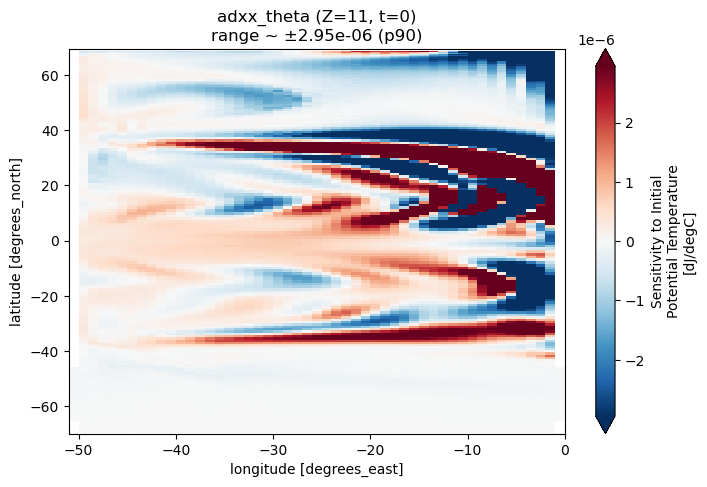

In [22]:
# Select data
t_index = 0
z_index = 11

da = ds_adxx.adxx_theta.isel(time=t_index, Z=z_index)

# Apply ocean mask
da = da.where(ds_adxx.hFacC.isel(Z=z_index) > 0) # hFacC = fraction of open water in a grid cell. 
# Values: 1 → fully ocean, 0 → land, between 0–1 → partial cell (bottom topography)

# Compute robust limits (avoid outliers)
arr = da.values # Converts your xarray.DataArray → 2D NumPy array | Drops coordinates (XC, YC, etc.), Keeps only numerical values
arr = arr[np.isfinite(arr)] # Keeps only real numbers. Removes NaN from masking. arr → 1D array of valid ocean values. arr[mask] implicitly flattens the array.

p = 90  # percentile. If you set p = 90, you are ingnoring the top 10% most extreme values
vmax = np.percentile(np.abs(arr), p) # if p = 90, This returns the value such that 90% of data is below it and 10% are larger (outliers)
vmin = -vmax

# Plot
plt.figure(figsize=(8,5))
da.plot(
    vmin=vmin,
    vmax=vmax,
    cmap='RdBu_r'
)

plt.title(f"adxx_theta (Z={z_index}, t={t_index})\n"
          f"range ~ ±{vmax:.2e} (p{p})")
plt.show()

Plotting adxx_theta


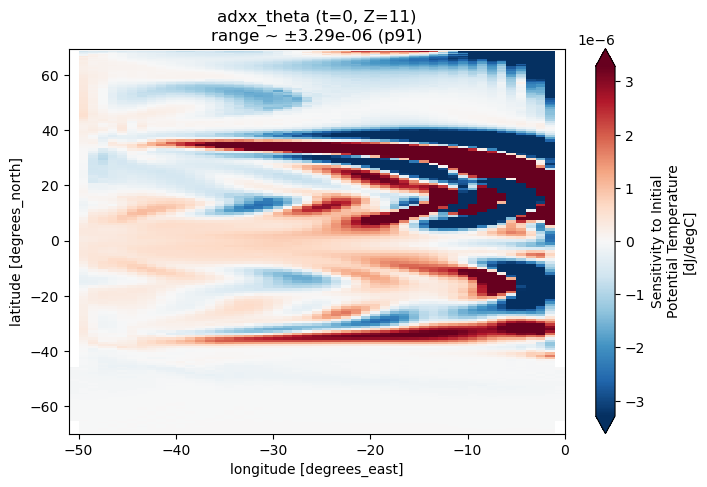

Plotting adxx_salt


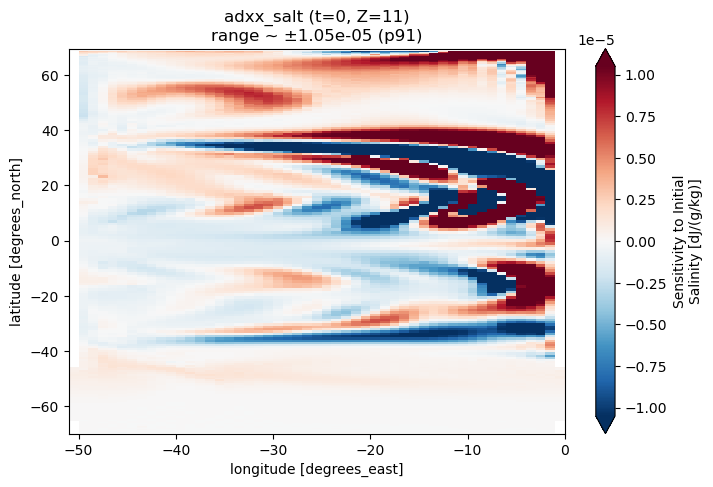

Plotting adxx_diffkr


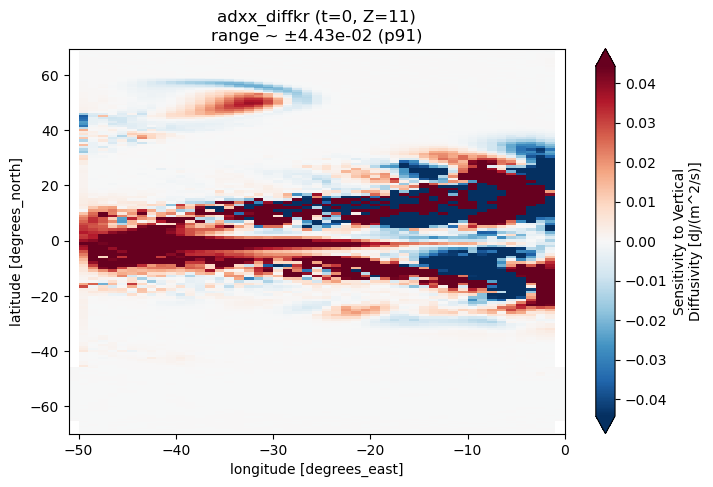

Plotting adxx_fu


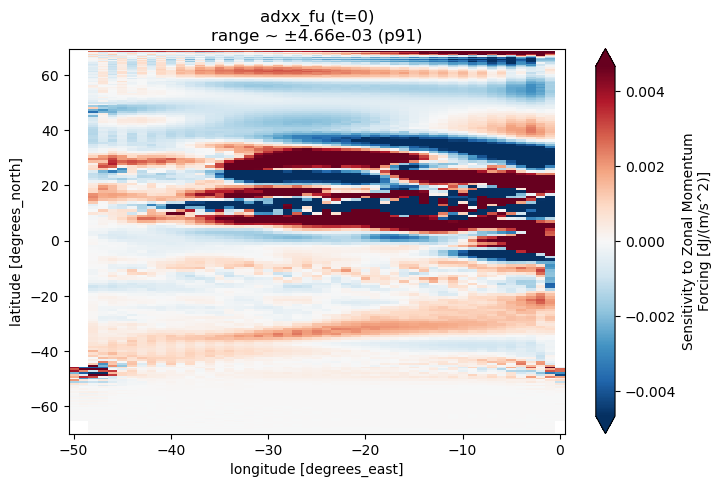

Plotting adxx_fv


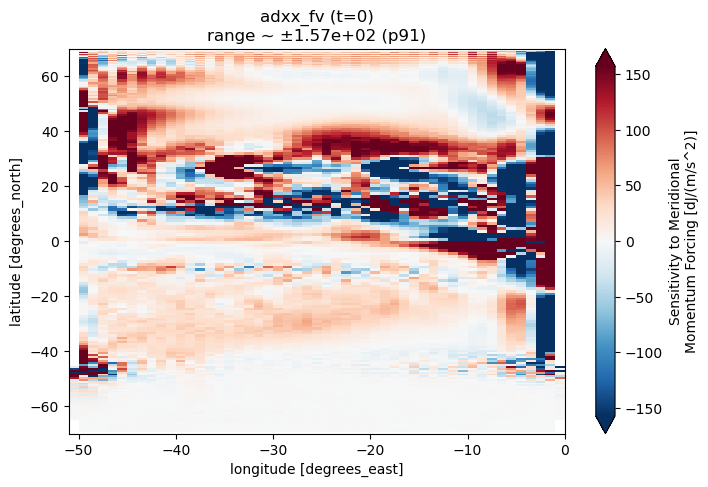

Plotting adxx_qnet


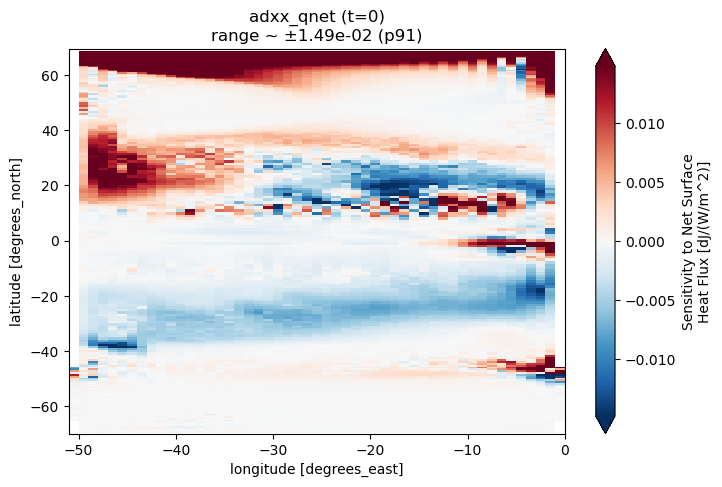

Plotting adxx_qsw


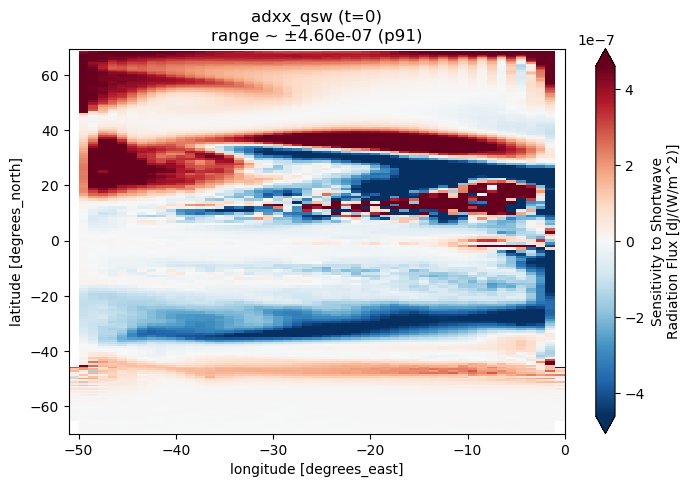

Plotting adxx_empmr


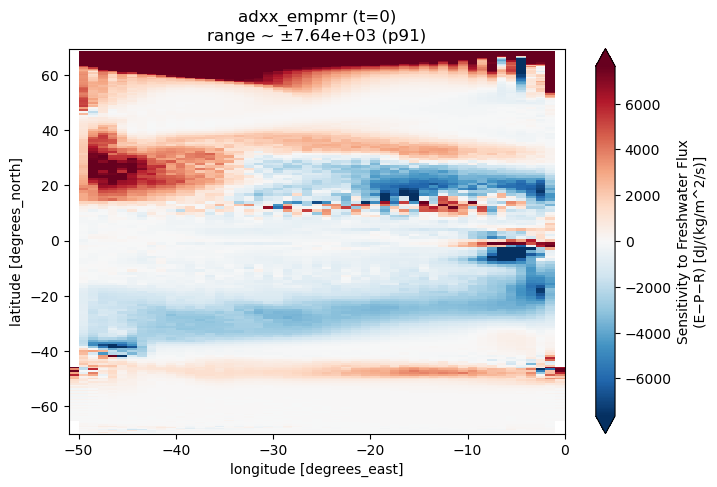

In [23]:
# --- settings ---
t_index = 0
z_index = 11
p = 91  # percentile for robust scaling

# list of variables you want
adxx_vars = [
    "adxx_theta",
    "adxx_salt",
    "adxx_diffkr",
    "adxx_fu",
    "adxx_fv",
    "adxx_qnet",
    "adxx_qsw",
    "adxx_empmr"
]

for var in adxx_vars:

    if var not in ds_adxx:
        print(f"{var} not found, skipping.")
        continue

    print(f"Plotting {var}")

    # --- select data ---
    da = ds_adxx[var]

    # Handle 3D vs 2D variables
    if 'Z' in da.dims:
        da = da.isel(time=t_index, Z=z_index)
    
        if 'XG' in da.dims:
            mask = ds_adxx.hFacW.isel(Z=z_index) > 0
        elif 'YG' in da.dims:
            mask = ds_adxx.hFacS.isel(Z=z_index) > 0
        else:
            mask = ds_adxx.hFacC.isel(Z=z_index) > 0
    
    else:
        da = da.isel(time=t_index)
    
        if 'XG' in da.dims:
            mask = ds_adxx.hFacW.isel(Z=0) > 0
        elif 'YG' in da.dims:
            mask = ds_adxx.hFacS.isel(Z=0) > 0
        else:
            mask = ds_adxx.hFacC.isel(Z=0) > 0

    # apply mask
    da = da.where(mask)

    # --- compute robust scaling ---
    arr = da.values
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        print(f"{var}: ALL NaN, skipping.")
        continue

    vmax = np.percentile(np.abs(arr), p)
    if not np.isfinite(vmax) or vmax == 0:
        vmax = np.nanmax(np.abs(arr))

    vmin = -vmax

    # --- plot ---
    plt.figure(figsize=(8,5))
    da.plot(
        vmin=vmin,
        vmax=vmax,
        cmap='RdBu_r'
    )

    plt.title(f"{var} (t={t_index}"
              + (f", Z={z_index}" if 'Z' in ds_adxx[var].dims else "")
              + f")\nrange ~ ±{vmax:.2e} (p{p})")

    plt.show()

## Animation of ADJ Fields

In [24]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [25]:
def animate_ADJ_3d(var, ds, zlev=11, interval_ms=500, p=95):
    """
    Animate 3D ADJ variable (ADJtheta, ADJsalt, ADJdiffkr)
    at a fixed depth with robust scaling.
    
    Parameters:
    - var : variable name
    - ds : dataset
    - zlev : depth index
    - interval_ms : animation speed
    - p : percentile for robust scaling (default 95)
    """

    # --- check variable ---
    if var not in ds:
        print(f"{var} not in dataset.")
        return

    if var not in ["ADJtheta", "ADJsalt", "ADJdiffkr"]:
        print(f"{var} not in selected 3D variables.")
        return

    da = ds[var].isel(Z=zlev)

    # --- apply ocean mask ---
    if 'hFacC' in ds:
        mask = ds.hFacC.isel(Z=zlev) > 0
        da = da.where(mask)

    A = da.values

    # --- robust symmetric color scale ---
    finite = np.isfinite(A)
    if finite.any():
        vmax = np.percentile(np.abs(A[finite]), p)
        if not np.isfinite(vmax) or vmax == 0:
            vmax = np.nanmax(np.abs(A[finite]))
        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0
    else:
        vmax = 1.0

    vmin = -vmax

    print(f"{var}: Z={zlev}, scale=±{vmax:.3e} (p{p})")

    # --- time labels ---
    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # --- figure setup ---
    fig, ax = plt.subplots(figsize=(10, 5))

    pcm = da.isel(time=0).plot(
        x='XC', y='YC',
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(ds[var].attrs.get("long_name", var))

    title = ax.set_title(f"{var} • Z={zlev} • time={tlabel(0)}")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # --- update function ---
    def update(i):
        frame = da.isel(time=i).values

        # IMPORTANT: avoid NaN rendering issues
        frame = np.where(np.isfinite(frame), frame, np.nan)

        pcm.set_array(frame.ravel())
        title.set_text(f"{var} • Z={zlev} • time={tlabel(i)}")

        return pcm, title

    # reverse time (adjoint runs backward)
    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval_ms,
        blit=False
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [26]:
animate_ADJ_3d("ADJtheta", ds_adj, zlev=11, p=95)

ADJtheta: Z=11, scale=±9.125e-06 (p95)


<IPython.core.display.HTML object>
[text/html animation output (24.4 MB) stripped to keep this notebook pushable - re-run this cell to regenerate]

Note about the Above Plot

I had to plot the ADJtheta file in the reverse order of the timestep. This is because, ami forward model er time step use kortesi ADJtheta file k numbering korar jonno. But adjoint runs backward in time. So jokhon plot korbo tokhon seta ke reverse timestep order e plot korte hobe.

"ADJtheta.0000000000.data" data in this file should closely corresponds to the data in the file "adxx_theta.0000000000.data"


For 5 years run (Starting from 2055-02-06), Stable untile 3 years, 3 months, and 22 days. After 2051-10-15, the values become very large and blows up.

For 10 years run (staring from 2060-02-10), Stable 5 years, 6 months, and 10 days. After 2054-07-31, the values become very large and blows up

In [ ]:
animate_ADJ_3d("ADJsalt", ds_adj, zlev=11, p=65)

In [ ]:
animate_ADJ_3d("ADJdiffkr", ds_adj, zlev=11, p=80)

In [ ]:
def animate_ADJ_2d(var, ds, mask_level=0, interval_ms=500, p=95):
    """
    Animate a 2D ADJ field over time.
    Works for XC/YC, XG/YC, XC/YG (all staggered grids).

    Parameters:
    - p : percentile for robust scaling (default 95)
    """

    if var not in ds:
        print(f"{var} not found in dataset.")
        return

    da = ds[var]

    # Apply mask only for tracer grid
    if 'hFacC' in ds and 'XC' in da.dims and 'YC' in da.dims:
        mask = ds.hFacC.isel(Z=mask_level) > 0
        da = da.where(mask)

    A = da.values

    # robust symmetric color scale (UPDATED)
    if np.isfinite(A).any():
        v = np.nanpercentile(np.abs(A), p)
        if v == 0 or not np.isfinite(v):
            v = 1.0
    else:
        v = 1.0

    vmin, vmax = -v, v

    print(f"{var}: shape={A.shape}, scale=±{v:.3e} (p{p})")

    # time helper
    tcoord = da['time'].values
    def tlabel(i):
        try:
            return str(np.datetime_as_string(tcoord[i], unit='D'))
        except Exception:
            return str(tcoord[i])

    # grid-aware
    xcoord = 'XC' if 'XC' in da.dims else 'XG'
    ycoord = 'YC' if 'YC' in da.dims else 'YG'

    # --- figure ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # initial plot
    pcm = da.isel(time=0).plot(
        x=xcoord, y=ycoord,
        cmap='RdBu_r',
        vmin=vmin, vmax=vmax,
        add_colorbar=False,
        ax=ax
    )

    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(da.attrs.get('long_name', var))

    title = ax.set_title(f"{var} • time={tlabel(0)}")

    # update
    def update(i):
        ax.clear()

        da.isel(time=i).plot(
            x=xcoord, y=ycoord,
            cmap='RdBu_r',
            vmin=vmin, vmax=vmax,
            add_colorbar=False,
            ax=ax
        )

        ax.set_title(f"{var} • time={tlabel(i)}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

        return ax,

    frames = list(reversed(range(da.sizes['time'])))

    anim = FuncAnimation(fig, update, frames=frames,
                         interval=interval_ms, blit=False)

    plt.close(fig)
    return HTML(anim.to_jshtml())

In [ ]:
animate_ADJ_2d("ADJtaux", ds_adj, p=68)

In [ ]:
animate_ADJ_2d("ADJtauy", ds_adj, p=68)

In [ ]:
animate_ADJ_2d("ADJqnet", ds_adj, p=62)

In [ ]:
animate_ADJ_2d("ADJqsw", ds_adj, p=62)

In [ ]:
animate_ADJ_2d("ADJempmr", ds_adj, p=62)